# 13 · Object detection in micrographs (optional)

*Refreshed from the original Summer-School YOLO notebook.*

Clustering and CNNs classify **what** a region is; **object detection** also
finds **where** things are — drawing a box around each defect, particle, or
indent and giving it a class + confidence. The de-facto tool is **YOLO**
(via the `ultralytics` package).

> **Optional / heavy.** This notebook needs `pip install ultralytics` and, for
> real training, a labelled image set. It is written to run *gracefully* even
> when those are absent, so it never blocks the rest of the tutorial.

In [1]:
# --- setup: find the repo (auto-clone on Colab), load helpers, set plot style ---
import os, sys, subprocess
def _find_src():
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None
if _find_src() is None:                    # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)
sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mecanano_ml as mm
mm.set_style()
print("helpers loaded from:", mm.__file__)

helpers loaded from: /tmp/stage/repo/src/mecanano_ml/__init__.py


In [2]:
# Optional dependency — the notebook degrades gracefully if it is missing.
try:
    from ultralytics import YOLO
    HAVE_YOLO = True
except Exception as e:
    HAVE_YOLO = False
    print("ultralytics not installed — running in illustration mode.")
    print("  enable the real detector with:  pip install ultralytics")

ultralytics not installed — running in illustration mode.
  enable the real detector with:  pip install ultralytics


## 1 · What a detector returns
For each object: a bounding **box**, a **class**, and a **confidence**. Here is a synthetic micrograph with a few 'defects' and the kind of boxes a detector would output.

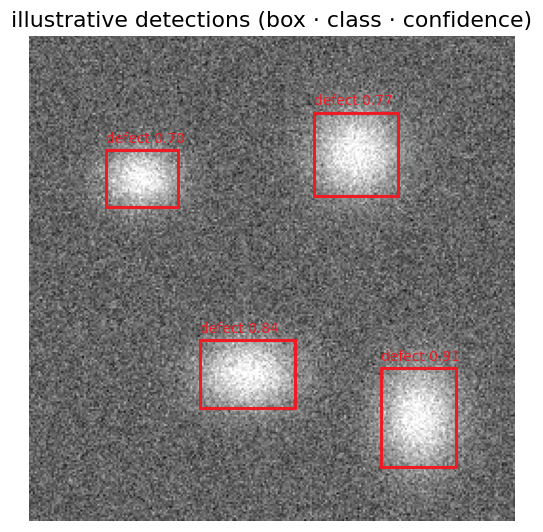

In [3]:
from matplotlib.patches import Rectangle
rng = np.random.default_rng(1)
img = rng.normal(0.5, 0.08, (256, 256))
boxes = [(40,60,38,30), (150,40,44,44), (90,160,50,36), (185,175,40,52)]
for x,y,w,h in boxes:                                   # embed brighter blobs
    yy,xx = np.ogrid[:256,:256]
    img += 0.5*np.exp(-(((xx-(x+w/2))/(w/2))**2 + ((yy-(y+h/2))/(h/2))**2))
img = np.clip(img,0,1)
fig, ax = plt.subplots(figsize=(5,5)); ax.imshow(img, cmap="gray")
for i,(x,y,w,h) in enumerate(boxes):
    ax.add_patch(Rectangle((x,y),w,h, fill=False, ec="#ED1C24", lw=2))
    ax.text(x, y-4, f"defect {0.7+0.07*i:.2f}", color="#ED1C24", fontsize=9)
ax.set_title("illustrative detections (box · class · confidence)"); ax.axis("off"); fig.tight_layout()

## 2 · Running a real YOLO model
If `ultralytics` is installed (and a model can be fetched), this runs actual inference; otherwise it is skipped.

In [4]:
if HAVE_YOLO:
    try:
        import matplotlib.image as mpimg
        os.makedirs("/tmp/yolo_demo", exist_ok=True)
        plt.imsave("/tmp/yolo_demo/sample.png", img, cmap="gray")
        model = YOLO("yolov8n.pt")                       # tiny pretrained model
        res = model("/tmp/yolo_demo/sample.png", verbose=False)
        fig, ax = plt.subplots(figsize=(5,5)); ax.imshow(res[0].plot()[..., ::-1]); ax.axis("off"); ax.set_title("YOLOv8 output")
        print("detections:", len(res[0].boxes))
    except Exception as e:
        print("YOLO available but inference skipped (offline model fetch?):", type(e).__name__)
else:
    print("Skipped — install ultralytics to run the real detector.")

Skipped — install ultralytics to run the real detector.


## 3 · Training on your own micrographs

1. Label a few hundred images (boxes + classes) with a tool like **Roboflow**,
   **labelImg**, or **CVAT**; export in **YOLO format**.
2. Point a `data.yaml` at your `train/` and `val/` folders and class names.
3. Fine-tune from a small pretrained model:

```python
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
model.train(data="data.yaml", epochs=100, imgsz=640)
```

4. Validate on held-out images and **report precision/recall per class** — the
   same honesty as everywhere else in this tutorial.

## Recap
- **Detection = classification + localisation.** YOLO is the practical default.
- Use it for locating defects, precipitates, or indents in micrographs.
- This notebook is optional; the core nanoindentation ML story lives in 00–06.